# BESTEST Cases 900–995 summary

Annual, peak, solar, and native-ISO results for the conditioned 9XX family.

In [1]:
from pathlib import Path
import sys,pandas as pd,matplotlib.pyplot as plt
from IPython.display import display
cwd=Path.cwd().resolve()
root=next((p for p in (cwd,*cwd.parents) if (p/'validation/bestest_iso_reporting.py').is_file()),None)
if root is None: raise FileNotFoundError('Could not locate the BESTEST repository root')
sys.path.insert(0,str(root/'validation'))
from bestest_iso_reporting import completed_hour_label
from bestest_iso_case9xx_reporting import annual_tracks,comparison_table,peak_tracks
CASES=('900','910','920','930','940','950','980','985','995')
metrics={case:pd.read_csv(root/'results'/'1_iso'/f'case{case}'/f'case{case}_metrics.csv') for case in CASES}

## Annual heating and cooling

Heating MWh                                      \
Run  Modelica native RClib-ISO + Modelica-resolved solar   
Case                                                       
900         1.832767                            1.818536   
910         2.283600                            2.269473   
920         3.649996                            3.635015   
930         4.182855                            4.168666   
940         1.241928                            1.150732   
950         0.000000                            0.000000   
980         0.494186                            0.486971   
985         2.332906                            2.309594   
995         0.927361                            0.912631   

                                Cooling MWh  \
Run  RClib-ISO native solar Modelica native   
Case                                          
900                4.790196        2.284410   
910                5.049023        1.674521   
920                3.539694        2.684319   
930                4.101262        1.920117   
940                3.793795        2.250527   
950                0.000000        0.638195   
980                2.601259        3.657672   
985                4.828186        5.905086   
995                2.685414        7.077424   

                                                                 
Run  RClib-ISO + Modelica-resolved solar RClib-ISO native solar  
Case                                                             
900                             2.284475               0.614339  
910                             1.674888               0.498504  
920                             2.688719               2.109828  
930                             1.923263               1.497710  
940                             2.246702               0.613485  
950                             0.654680               0.101758  
980                             3.665299               0.833657  
985                             5.897670               2.521523  
995                             7.079672               2.508742

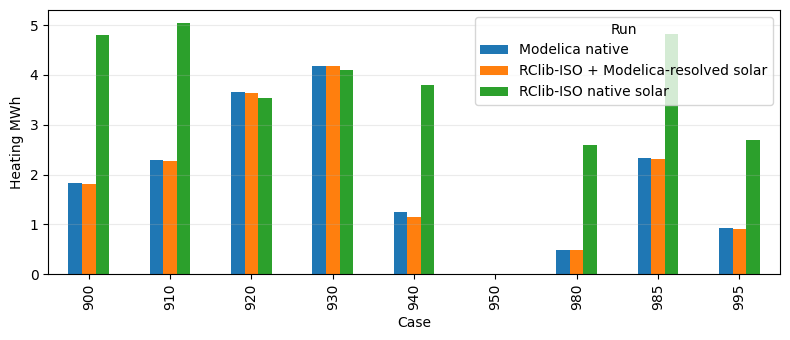

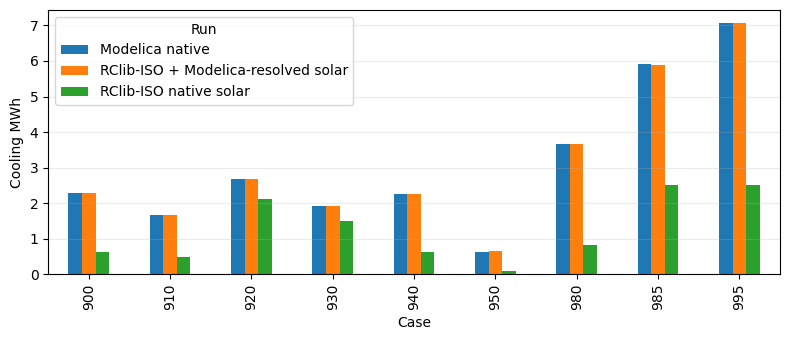

In [2]:
annual=pd.concat([annual_tracks(metrics[case]).assign(Case=case) for case in CASES]); display(annual.pivot(index='Case',columns='Run',values=['Heating MWh','Cooling MWh']))
for metric in ('Heating MWh','Cooling MWh'):
    fig,ax=plt.subplots(figsize=(8,3.5)); annual.pivot(index='Case',columns='Run',values=metric).plot(kind='bar',ax=ax); ax.set_ylabel(metric); ax.grid(axis='y',alpha=.25); fig.tight_layout(); plt.show()

## Controlled-forcing residuals, peaks, and solar

In [3]:
residual=pd.concat([comparison_table(metrics[case],'controlled_modelica').assign(Case=case) for case in CASES]); display(residual.pivot(index='Case',columns='Metric',values='Difference %'))
peaks=pd.concat([peak_tracks(metrics[case],completed_hour_label).assign(Case=case) for case in CASES]); display(peaks)
solar=[]
for case in CASES:
    values=pd.read_csv(root/'results'/'1_iso'/f'case{case}'/f'case{case}_solar_comparison.csv').set_index('quantity').value
    solar.append({'Case':case,'Native solar MWh':values['native_rclib_zone_solar_MWh'],'Modelica solar MWh':values['modelica_resolved_zone_solar_MWh']})
display(pd.DataFrame(solar))

Metric,Annual cooling,Annual heating,Peak cooling,Peak heating
Case,,,,
900,0.002844,-0.776507,0.321234,0.259858
910,0.021928,-0.618643,-0.005885,0.212914
920,0.163882,-0.410444,-0.978462,0.149123
930,0.163842,-0.339222,-0.980873,0.098747
940,-0.169958,-7.343051,0.334653,-2.499405
950,2.583082,NaN,-0.405030,NaN
980,0.208522,-1.459907,-0.053164,0.284213
985,-0.125597,-0.999273,0.108061,0.243887
995,0.031768,-1.588322,-0.189416,0.253727


,Track,Peak heating kW,Peak heating time,Peak cooling kW,Peak cooling time,Case
0,Modelica native,2.639677,09-Feb:06,2.365476,01-Oct:15,900
1,RClib-ISO native solar,2.744090,09-Feb:06,1.352340,14-Jun:18,900
2,RClib-ISO + Modelica-resolved solar,2.646536,09-Feb:06,2.373074,01-Oct:15,900
0,Modelica native,2.677942,09-Feb:06,2.011181,11-Sep:15,910
1,RClib-ISO native solar,2.759963,09-Feb:06,1.254802,14-Jun:18,910
2,RClib-ISO + Modelica-resolved solar,2.683644,09-Feb:06,2.011063,11-Sep:15,910
0,Modelica native,2.727867,09-Feb:06,2.797514,26-Jun:18,920
1,RClib-ISO native solar,2.726149,09-Feb:06,2.522977,26-Jun:17,920
2,RClib-ISO + Modelica-resolved solar,2.731935,09-Feb:06,2.770142,26-Jun:18,920
0,Modelica native,2.760117,09-Feb:06,2.366486,26-Jun:18,930


,Case,Native solar MWh,Modelica solar MWh
0,900,4.270377,12.112389
1,910,3.653750,10.247074
2,920,8.625660,9.349927
3,930,6.771119,7.340286
4,940,4.270377,12.112389
5,950,4.270377,12.112389
6,980,3.972237,11.562587
7,985,4.270377,12.112389
8,995,3.972237,11.562587


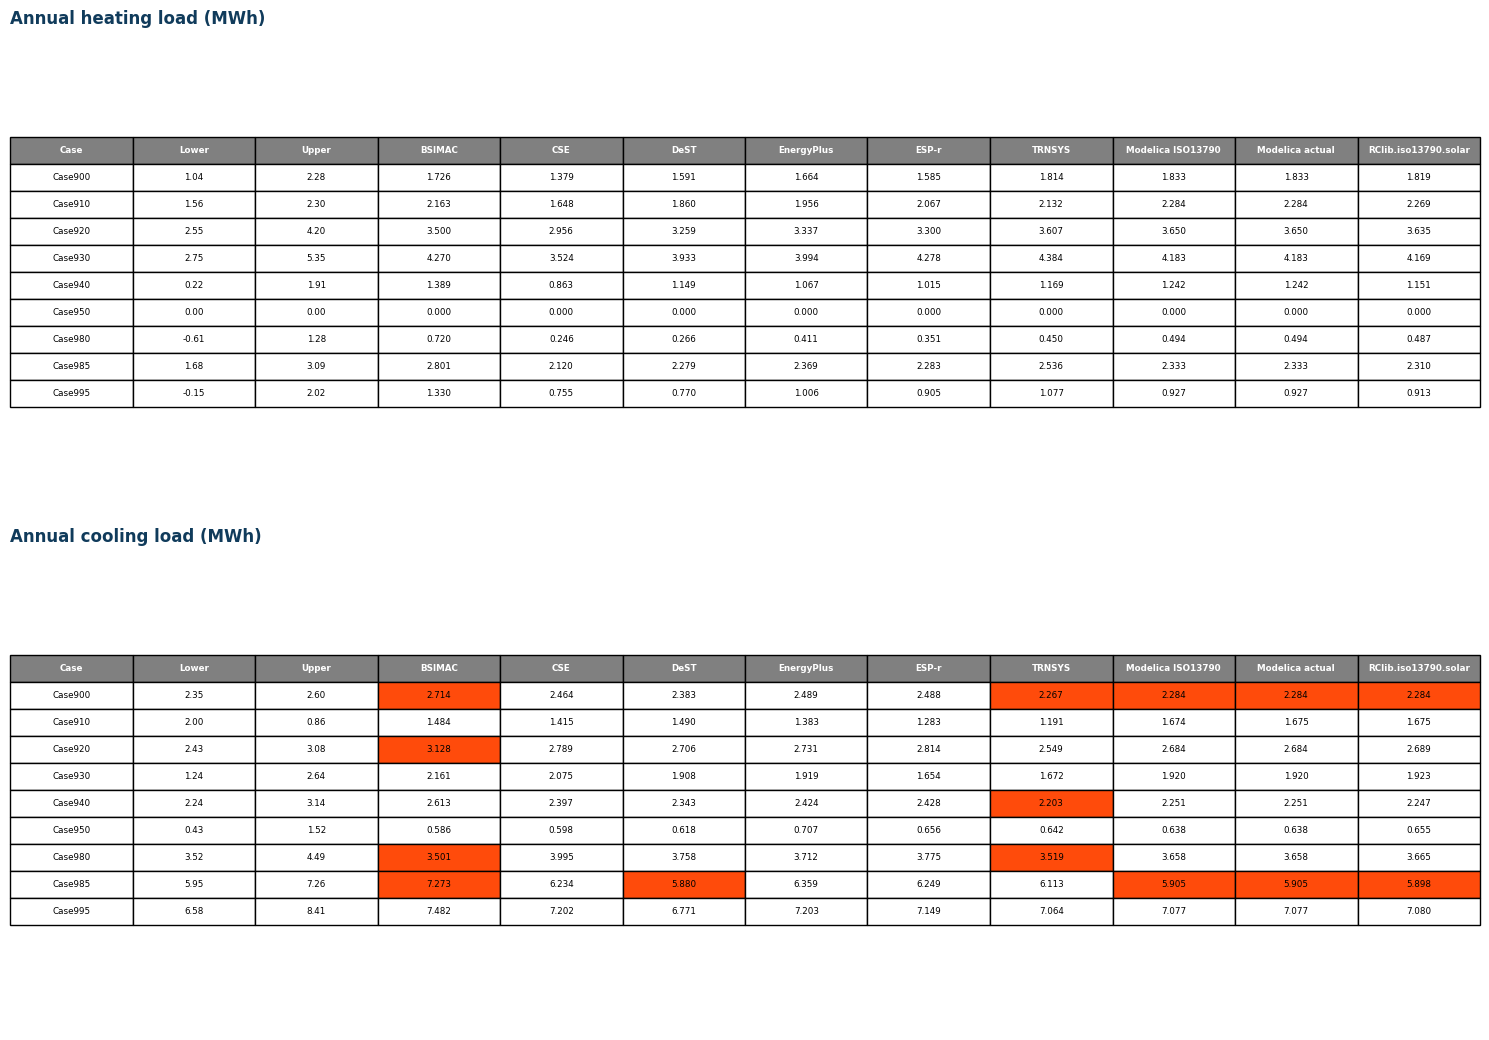

,case,metric,actual_modelica_MWh,native_iso_MWh,actual_modelica_status,native_iso_status
11,900,heating,1.832767,4.790196,PASS,FAIL
12,910,heating,2.283600,5.049023,PASS,FAIL
13,920,heating,3.649996,3.539694,PASS,PASS
14,930,heating,4.182855,4.101262,PASS,PASS
15,940,heating,1.241928,3.793795,PASS,FAIL
16,950,heating,0.000000,0.000000,PASS,PASS
17,980,heating,0.494186,2.601259,PASS,FAIL
18,985,heating,2.332906,4.828186,PASS,FAIL
19,995,heating,0.927361,2.685414,PASS,FAIL
31,900,cooling,2.284410,0.614339,FAIL,FAIL


In [4]:
from bestest_iso_plot_ashrae140_annual_matrix import build_summary, draw_table
matrix = build_summary()
family_cases = ('900', '910', '920', '930', '940', '950', '980', '985', '995')
fig, axes = plt.subplots(2, 1, figsize=(15, 10.5))
draw_table(axes[0], 'heating', matrix, family_cases)
draw_table(axes[1], 'cooling', matrix, family_cases)
fig.tight_layout(); plt.show()
display(matrix[matrix.case.isin(family_cases)][['case', 'metric', 'actual_modelica_MWh', 'native_iso_MWh', 'actual_modelica_status', 'native_iso_status']])

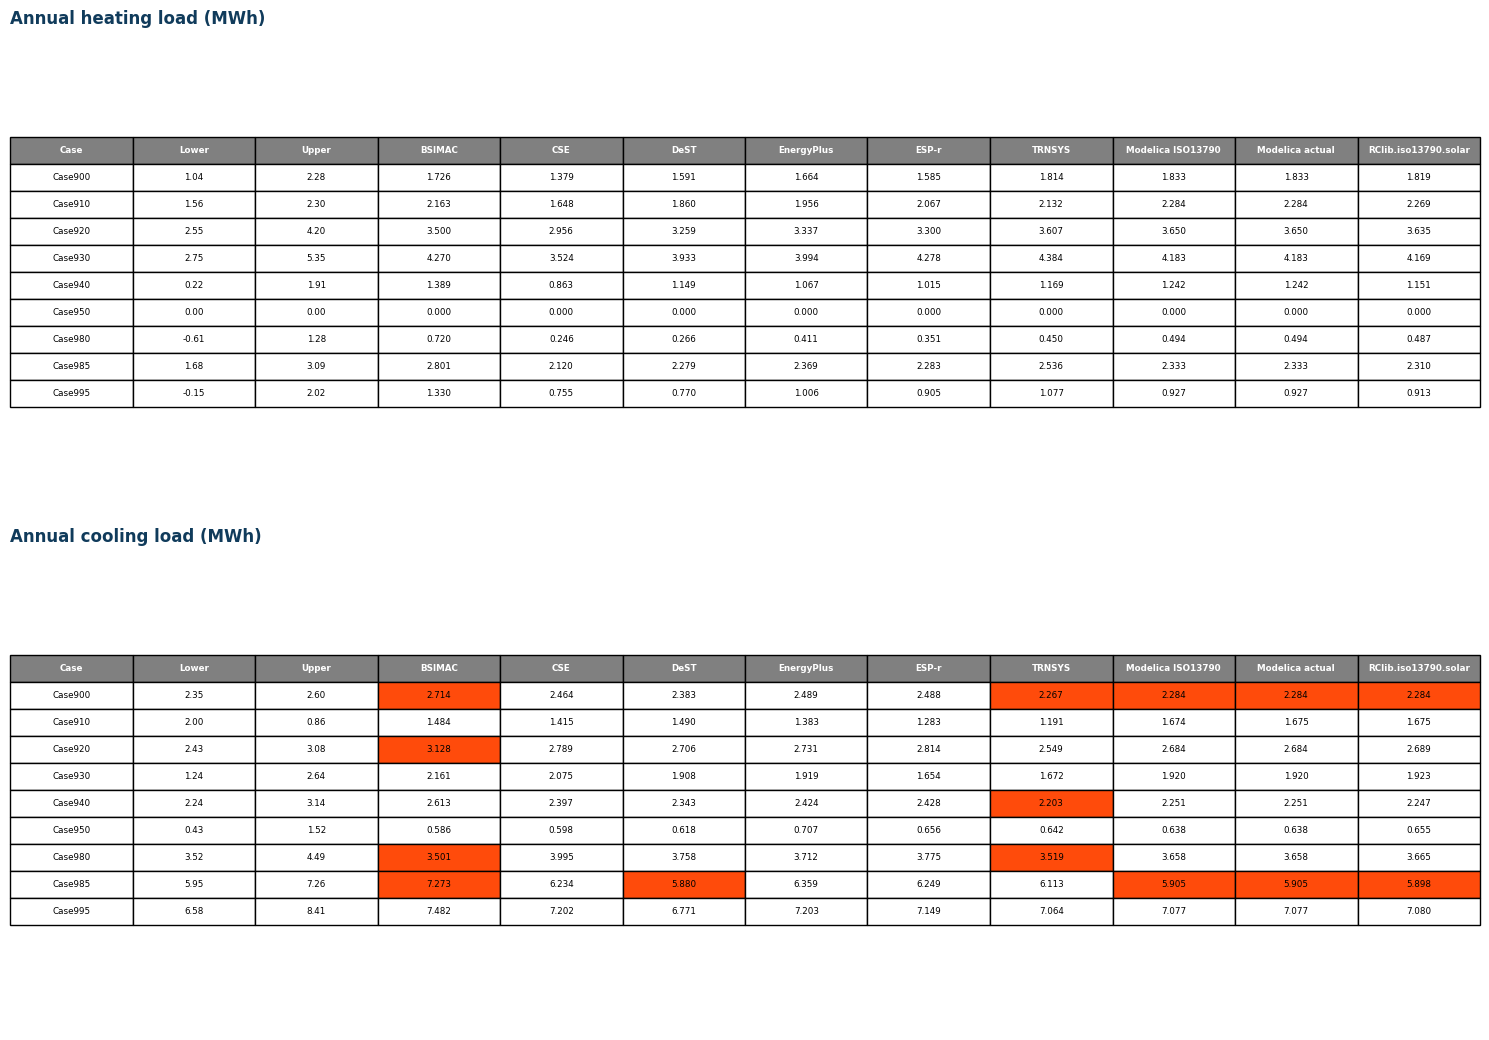

,case,metric,actual_modelica_MWh,rclib_iso_modelica_solar_MWh,actual_modelica_status
11,900,heating,1.832767,1.818536,PASS
12,910,heating,2.283600,2.269473,PASS
13,920,heating,3.649996,3.635015,PASS
14,930,heating,4.182855,4.168666,PASS
15,940,heating,1.241928,1.150732,PASS
16,950,heating,0.000000,0.000000,PASS
17,980,heating,0.494186,0.486971,PASS
18,985,heating,2.332906,2.309594,PASS
19,995,heating,0.927361,0.912631,PASS
31,900,cooling,2.284410,2.284475,FAIL


In [5]:
from bestest_iso_plot_ashrae140_annual_matrix import build_summary, draw_table
matrix = build_summary()
family_cases = ('900', '910', '920', '930', '940', '950', '980', '985', '995')
fig, axes = plt.subplots(2, 1, figsize=(15, 10.5))
draw_table(axes[0], 'heating', matrix, family_cases)
draw_table(axes[1], 'cooling', matrix, family_cases)
fig.tight_layout(); plt.show()
display(matrix[matrix.case.isin(family_cases)][['case', 'metric', 'actual_modelica_MWh', 'rclib_iso_modelica_solar_MWh', 'actual_modelica_status']])

## Annual ASHRAE 140 matrix

LBNL-style annual heating and cooling tables. Red cells are outside valid published acceptance bounds; native ISO is the formal Python result.

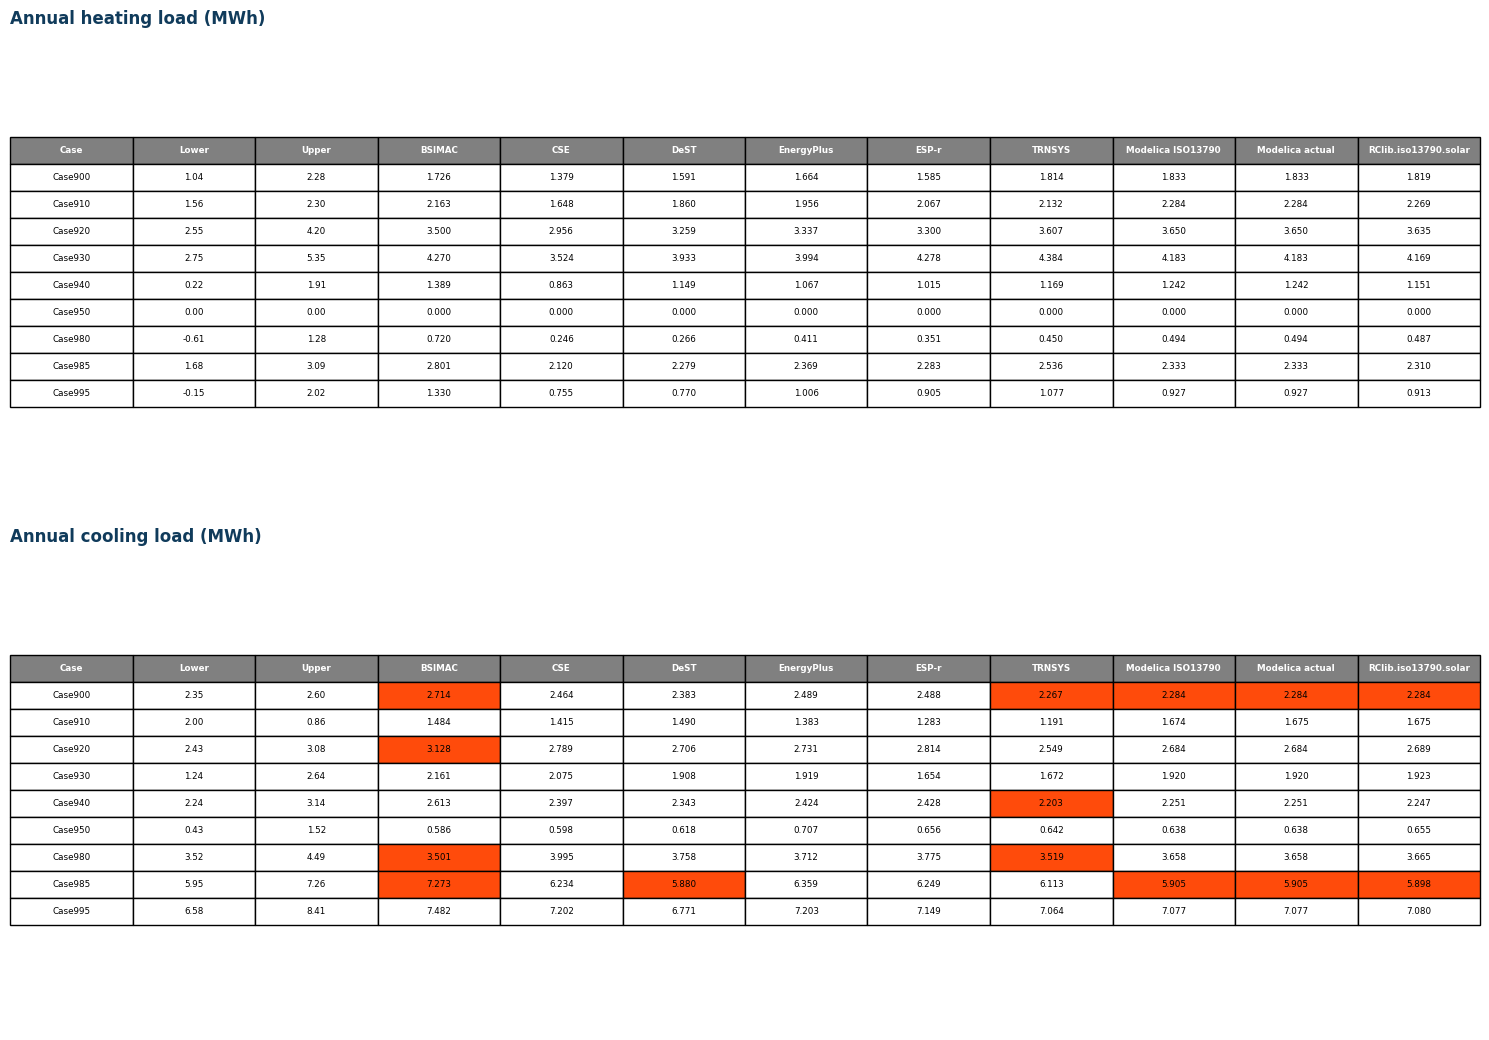

,case,metric,actual_modelica_MWh,rclib_iso_modelica_solar_MWh,actual_modelica_status
11,900,heating,1.832767,1.818536,PASS
12,910,heating,2.283600,2.269473,PASS
13,920,heating,3.649996,3.635015,PASS
14,930,heating,4.182855,4.168666,PASS
15,940,heating,1.241928,1.150732,PASS
16,950,heating,0.000000,0.000000,PASS
17,980,heating,0.494186,0.486971,PASS
18,985,heating,2.332906,2.309594,PASS
19,995,heating,0.927361,0.912631,PASS
31,900,cooling,2.284410,2.284475,FAIL


In [6]:
from bestest_iso_plot_ashrae140_annual_matrix import build_summary, draw_table
matrix = build_summary()
family_cases = ('900', '910', '920', '930', '940', '950', '980', '985', '995')
fig, axes = plt.subplots(2, 1, figsize=(15, 10.5))
draw_table(axes[0], 'heating', matrix, family_cases)
draw_table(axes[1], 'cooling', matrix, family_cases)
fig.tight_layout(); plt.show()
display(matrix[matrix.case.isin(family_cases)][['case', 'metric', 'actual_modelica_MWh', 'rclib_iso_modelica_solar_MWh', 'actual_modelica_status']])